In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import matplotlib
#import fitutils as fu
from scipy.signal import find_peaks
import os
import pickle
import csv
import re
import sys
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from scipy.interpolate import LinearNDInterpolator

matplotlib.rcParams['font.sans-serif'] = "Times New Roman"

In [2]:
#file_dict_results = 'R:/Gre25/Summary/fracture_postprocessing/resultats/fracture_results_version_csi.pkl'
#file_dict_results = 'R:/Gre25/Summary/fracture_postprocessing/resultats/fracture_results.pkl'

file_dict_results = 'D:/Grenoble/Gre25/Summary/fracture_postprocessing/resultats/fracture_results.pkl'

with open(file_dict_results, 'rb') as f:
    dict_results = pickle.load(f)


In [3]:
dict_results

{'0506': {'image_sequence': {'kappa_c_vals': [np.float64(-0.08792012973997754),
    np.float64(-0.09498080487190443),
    np.float64(-0.09154264021279863),
    np.float64(-0.0901556773797779),
    np.float64(-0.09191590485574645)],
   'yindices': array([2, 3, 4, 5, 6]),
   'ypix': array([205., 237., 269., 301., 333.], dtype=float32),
   'ypix_surf': 400,
   'f_exc': 0.9597}},
 '0507': {'img_seq_3': {'kappa_c_vals': [np.float64(-0.07329216870580042),
    np.float64(-0.08820162166177531),
    np.float64(-0.08923062412251521),
    np.float64(-0.09930939564491083)],
   'yindices': array([2, 3, 4, 5]),
   'ypix': array([232., 264., 296., 328.], dtype=float32),
   'ypix_surf': 400,
   'f_exc': 0.95}},
 '0512': {'img_seq2': {'kappa_c_vals': [np.float64(-0.0939764489036994),
    np.float64(-0.09020897911020988),
    np.float64(-0.08933741178657913),
    np.float64(-0.08965445751500101)],
   'yindices': array([3, 4, 5, 6]),
   'ypix': array([354., 386., 418., 450.], dtype=float32),
   'ypix_sur

In [4]:
list_date = []
list_name_frac_file = []
tab_h_avg = []
tab_h_std = []

tab_kappa_avg = []
tab_kappa_std = []

tab_plot = []

tab_f_exc = []

for date in dict_results:
    for name_frac_file in dict_results[date]:
        list_date.append(date)
        list_name_frac_file.append(name_frac_file)
        print('olala',name_frac_file)
        kappa_c_vals = dict_results[date][name_frac_file]['kappa_c_vals']
        tab_kappa_avg.append(np.mean(kappa_c_vals))
        tab_kappa_std.append(np.std(kappa_c_vals))

        #data = np.loadtxt(f'R:/Gre25/Data/thicknesses/thicknesses_frac_{date}_{name_frac_file}.txt',skiprows=1)
        data = np.loadtxt(f'D:/Grenoble/Gre25/Data/thicknesses/thicknesses_frac_{date}_{name_frac_file}.txt',skiprows=1)

        tab_h_avg.append(np.nanmean(data[:,1]) * 1e-3)
        tab_h_std.append(np.nanstd(data[:,1]) * 1e-3) # epaisseur convertie en metres
        print('date : ',date)
        print(name_frac_file)
        print('average thickness (mm) : ',np.mean(data[:,1]))
        if ((date=='0523')&(name_frac_file=='img_seq1'))|((date=='0513')&(name_frac_file=='img_seq4')):
            tab_plot.append(False)
        else:
            tab_plot.append(True)

        if 'f_exc' in dict_results[date][name_frac_file]:
            tab_f_exc.append(dict_results[date][name_frac_file]['f_exc'])
        else:
            tab_f_exc.append(np.nan)

tab_h_avg = np.array(tab_h_avg)
tab_h_std = np.array(tab_h_std)
tab_kappa_avg = np.array(tab_kappa_avg)
tab_kappa_std = np.array(tab_kappa_std)

tab_plot = np.array(tab_plot)
indices2plot = np.where(tab_plot)[0]
indicesnot2plot = np.where(tab_plot==False)[0]

tab_f_exc = np.array(tab_f_exc)

print(tab_plot)
print(indices2plot)
print(indicesnot2plot)


olala image_sequence
date :  0506
image_sequence
average thickness (mm) :  3.724285714285714
olala img_seq_3
date :  0507
img_seq_3
average thickness (mm) :  4.383333333333334
olala img_seq2
date :  0512
img_seq2
average thickness (mm) :  2.85
olala img_seq4
date :  0513
img_seq4
average thickness (mm) :  5.5737499999999995
olala img_seq5
date :  0513
img_seq5
average thickness (mm) :  4.357142857142857
olala recherche_freq_puis_frac
date :  0522
recherche_freq_puis_frac
average thickness (mm) :  3.2388461538461537
olala img_seq1
date :  0523
img_seq1
average thickness (mm) :  5.449
olala img_seq3
date :  0523
img_seq3
average thickness (mm) :  5.312222222222222
olala img_seq_6
date :  0526
img_seq_6
average thickness (mm) :  2.28
olala img_seq_1
date :  0527
img_seq_1
average thickness (mm) :  2.5354545454545456
olala img_seq_2
date :  0527
img_seq_2
average thickness (mm) :  2.4827272727272724
olala img_seq_3
date :  0527
img_seq_3
average thickness (mm) :  1.05
olala img_seq_1
date 

<>:9: SyntaxWarning: invalid escape sequence '\k'
<>:16: SyntaxWarning: invalid escape sequence '\k'
<>:22: SyntaxWarning: invalid escape sequence '\k'
<>:9: SyntaxWarning: invalid escape sequence '\k'
<>:16: SyntaxWarning: invalid escape sequence '\k'
<>:22: SyntaxWarning: invalid escape sequence '\k'
C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_21936\1910483914.py:9: SyntaxWarning: invalid escape sequence '\k'
  ax.set_ylabel('$\kappa_{c}$ (m$^{-1}$)')
C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_21936\1910483914.py:16: SyntaxWarning: invalid escape sequence '\k'
  plt.plot(np.linspace(3e-3,6e-3),4.5 * (np.linspace(3e-3,6e-3))**(2/3),color='red',linestyle='--',label='$\kappa_{c} \propto h^{2/3}$')
C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_21936\1910483914.py:22: SyntaxWarning: invalid escape sequence '\k'
  ax.set_ylabel('$\kappa_{c}$ (m$^{-1}$)')


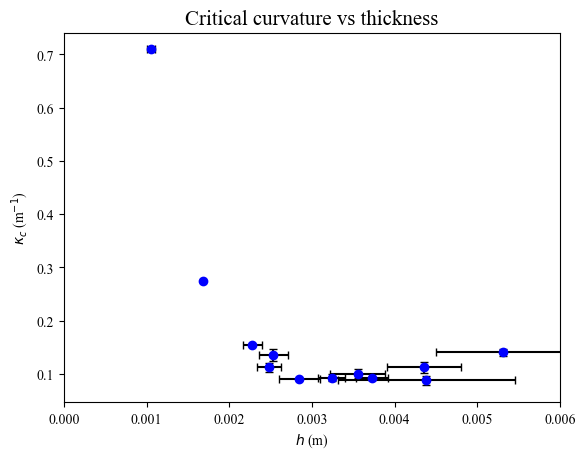

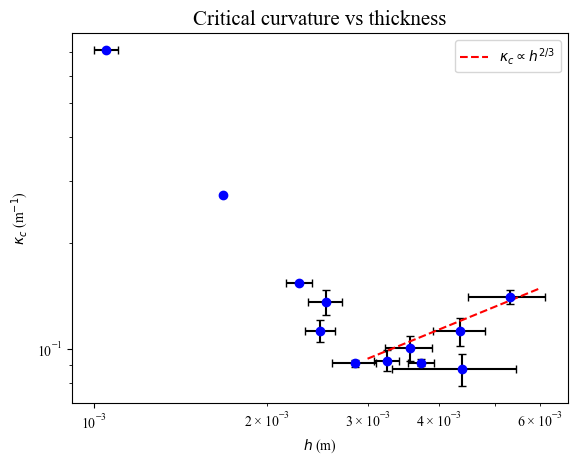

In [37]:
fig,ax = plt.subplots()
ax.errorbar(tab_h_avg[indices2plot],np.abs(tab_kappa_avg[indices2plot]),tab_kappa_std[indices2plot],xerr=tab_h_std[indices2plot],fmt='o',linestyle='',ecolor='black',capsize=3,color='blue')
#ax.errorbar(tab_h_avg[indicesnot2plot],np.abs(tab_kappa_avg[indicesnot2plot]),tab_kappa_std[indicesnot2plot],fmt='s',linestyle='',ecolor='black',capsize=3,color='red')

#ax.set_ylim(0,0.2)
ax.set_xlim(0,6e-3)
ax.set_title('Critical curvature vs thickness',fontsize=15)
ax.set_xlabel('$h$ (m)')
ax.set_ylabel('$\kappa_{c}$ (m$^{-1}$)')
plt.savefig('D:/Grenoble/Gre25/Summary/fracture_postprocessing/figures/kappac_vs_h.pdf',dpi=300)
plt.show()

fig,ax = plt.subplots()
ax.errorbar(tab_h_avg[indices2plot],np.abs(tab_kappa_avg[indices2plot]),tab_kappa_std[indices2plot],xerr=tab_h_std[indices2plot],fmt='o',linestyle='',ecolor='black',capsize=3,color='blue')
#ax.errorbar(tab_h_avg[indicesnot2plot],np.abs(tab_kappa_avg[indicesnot2plot]),tab_kappa_std[indicesnot2plot],fmt='s',linestyle='',ecolor='black',capsize=3,color='red')
plt.plot(np.linspace(3e-3,6e-3),4.5 * (np.linspace(3e-3,6e-3))**(2/3),color='red',linestyle='--',label='$\kappa_{c} \propto h^{2/3}$')
#ax.set_ylim(0,0.2)
#ax.set_xlim(0,6e-3)
plt.loglog()
ax.set_title('Critical curvature vs thickness',fontsize=15)
ax.set_xlabel('$h$ (m)')
ax.set_ylabel('$\kappa_{c}$ (m$^{-1}$)')
plt.legend()
plt.savefig('D:/Grenoble/Gre25/Summary/fracture_postprocessing/figures/kappac_vs_h_loglog.pdf',dpi=300)
plt.show()

In [6]:
%matplotlib inline

## déformation critique vs épaisseur

<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:36: SyntaxWarning: invalid escape sequence '\e'
<>:37: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:36: SyntaxWarning: invalid escape sequence '\e'
<>:37: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_21936\507485045.py:11: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel('$\epsilon_{c}$')
C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_21936\507485045.py:36: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel('$\epsilon_{c}$')
C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_21936\507485045.py:37: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(np.linspace(3e-3,6e-3),13 * (np.linspace(3e-3,6e-3))**2,color='red',linestyle='--',label='$\epsilon_{c} \propto h^{2}$')


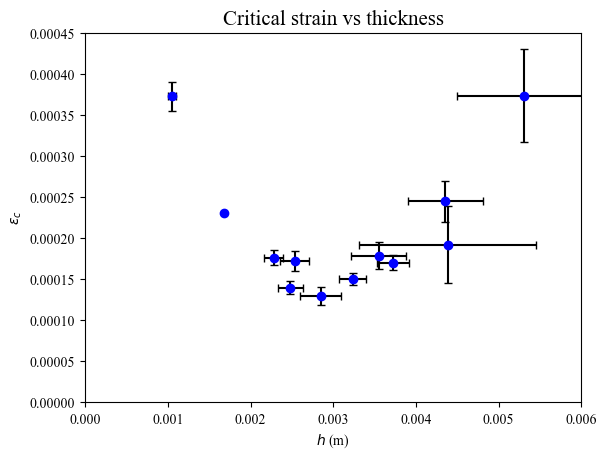

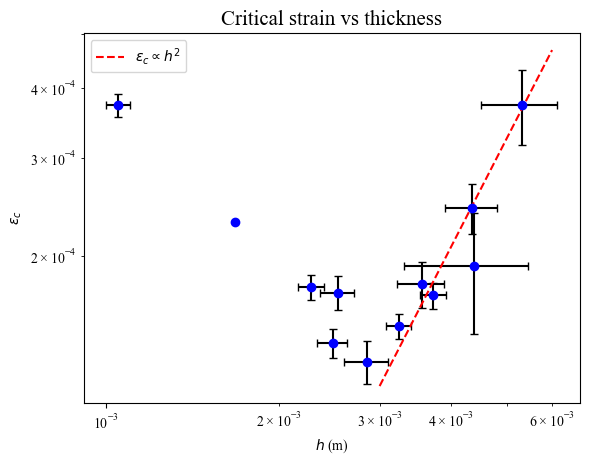

In [15]:
#plt.errorbar(tab_h_avg,np.abs(tab_kappa_avg) * tab_h_avg/2,tab_kappa_std*tab_h_avg/2,marker='o',linestyle='')
fig,ax = plt.subplots()

ax.errorbar(tab_h_avg[indices2plot],np.abs(tab_kappa_avg[indices2plot]) * tab_h_avg[indices2plot]/2,yerr=np.abs(tab_kappa_avg[indices2plot]) * tab_h_std[indices2plot]/2,xerr=tab_h_std[indices2plot],fmt='o',linestyle='',ecolor='black',capsize=3,color='blue')
#ax.errorbar(tab_h_avg[indicesnot2plot],np.abs(tab_kappa_avg[indicesnot2plot]) * tab_h_avg[indicesnot2plot]/2,xerr=tab_h_std[indicesnot2plot],yerr=np.abs(tab_kappa_avg[indicesnot2plot]) * tab_h_std[indicesnot2plot]/2,fmt='s',linestyle='',ecolor='black',capsize=3,color='red')

ax.set_xlim(0,6e-3)
ax.set_ylim(0,4.5e-4)
ax.set_title('Critical strain vs thickness',fontsize=15)
ax.set_xlabel('$h$ (m)')
ax.set_ylabel('$\epsilon_{c}$')
#plt.loglog()
plt.savefig('D:/Grenoble/Gre25/Summary/fracture_postprocessing/figures/epsilonc_vs_h.pdf',dpi=600)

#hth=np.linspace(1e-3,4e-3)
#ax.plot(hth,2e-4*(hth/2e-3)**(-1/2))
plt.show()





################
#ET EN LOGLOG
################
#plt.errorbar(tab_h_avg,np.abs(tab_kappa_avg) * tab_h_avg/2,tab_kappa_std*tab_h_avg/2,marker='o',linestyle='')
fig,ax = plt.subplots()

ax.errorbar(tab_h_avg[indices2plot],np.abs(tab_kappa_avg[indices2plot]) * tab_h_avg[indices2plot]/2,yerr=np.abs(tab_kappa_avg[indices2plot]) * tab_h_std[indices2plot]/2,xerr=tab_h_std[indices2plot],fmt='o',linestyle='',ecolor='black',capsize=3,color='blue')
#ax.errorbar(tab_h_avg[indicesnot2plot],np.abs(tab_kappa_avg[indicesnot2plot]) * tab_h_avg[indicesnot2plot]/2,xerr=tab_h_std[indicesnot2plot],yerr=np.abs(tab_kappa_avg[indicesnot2plot]) * tab_h_std[indicesnot2plot]/2,fmt='s',linestyle='',ecolor='black',capsize=3,color='red')

#ax.set_xlim(1e-3,6e-3)
#ax.set_ylim(1e-4,4.5e-4)
ax.set_title('Critical strain vs thickness',fontsize=15)
ax.set_xlabel('$h$ (m)')
ax.set_ylabel('$\epsilon_{c}$')
plt.plot(np.linspace(3e-3,6e-3),13 * (np.linspace(3e-3,6e-3))**2,color='red',linestyle='--',label='$\epsilon_{c} \propto h^{2}$')
plt.loglog()
plt.savefig('D:/Grenoble/Gre25/Summary/fracture_postprocessing/figures/epsilonc_vs_h_loglog.pdf',dpi=600)
plt.legend()
#hth=np.linspace(1e-3,4e-3)
#ax.plot(hth,2e-4*(hth/2e-3)**(-1/2))
plt.show()







<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_21936\4252362286.py:9: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('$f_{exc}\cdot\epsilon_{c}$ (s$^{-1}$)')
C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_21936\4252362286.py:10: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel('$\epsilon_{c}$')
C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_21936\4252362286.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


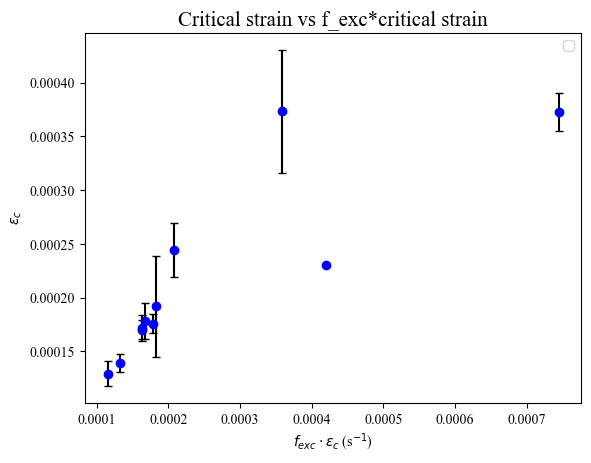

In [ ]:
# à plotter serieusement, en allant chercher les vraies valeurs de epsilon_point pour chaque manip juste avant la frac

"""
fig,ax = plt.subplots()

ax.errorbar(tab_f_exc[indices2plot] * np.abs(tab_kappa_avg[indices2plot]) * tab_h_avg[indices2plot]/2,np.abs(tab_kappa_avg[indices2plot]) * tab_h_avg[indices2plot]/2,yerr=np.abs(tab_kappa_avg[indices2plot]) * tab_h_std[indices2plot]/2,fmt='o',linestyle='',ecolor='black',capsize=3,color='blue')
#ax.errorbar(tab_h_avg[indicesnot2plot],np.abs(tab_kappa_avg[indicesnot2plot]) * tab_h_avg[indicesnot2plot]/2,xerr=tab_h_std[indicesnot2plot],yerr=np.abs(tab_kappa_avg[indicesnot2plot]) * tab_h_std[indicesnot2plot]/2,fmt='s',linestyle='',ecolor='black',capsize=3,color='red')

#ax.set_xlim(1e-3,6e-3)
#ax.set_ylim(1e-4,4.5e-4)
ax.set_title('Critical strain vs f_exc*critical strain',fontsize=15)
ax.set_xlabel('$f_{exc}\cdot\epsilon_{c}$ (s$^{-1}$)')
ax.set_ylabel('$\epsilon_{c}$')
#plt.plot(np.linspace(3e-3,6e-3),13 * (np.linspace(3e-3,6e-3))**2,color='red',linestyle='--',label='$\epsilon_{c} \propto h^{2}$')
#plt.loglog()
#plt.savefig('D:/Grenoble/Gre25/Summary/fracture_postprocessing/figures/epsilonc_vs_h_loglog.pdf',dpi=600)
plt.legend()
#hth=np.linspace(1e-3,4e-3)
#ax.plot(hth,2e-4*(hth/2e-3)**(-1/2))
plt.show()
"""

## contrainte critique vs épaisseur

<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_21936\2631066790.py:13: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel('$\sigma_{c}$')
C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_21936\2631066790.py:13: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel('$\sigma_{c}$')


FileNotFoundError: [Errno 2] No such file or directory: 'R:/Gre25/Summary/fracture_postprocessing/figures/sigmac_vs_h.pdf'

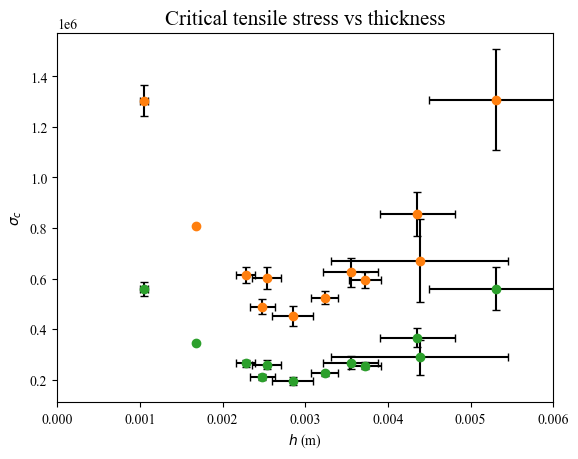

In [ ]:
#plt.errorbar(tab_h_avg,np.abs(tab_kappa_avg) * tab_h_avg/2,tab_kappa_std*tab_h_avg/2,marker='o',linestyle='')
fig,ax = plt.subplots()

ax.errorbar(tab_h_avg[indices2plot],3.5e9*np.abs(tab_kappa_avg[indices2plot]) * tab_h_avg[indices2plot]/2,yerr=3.5e9*np.abs(tab_kappa_avg[indices2plot]) * tab_h_std[indices2plot]/2,xerr=tab_h_std[indices2plot],fmt='o',linestyle='',ecolor='black',capsize=3,color='tab:orange',label='for E=3.5 GPa')
ax.errorbar(tab_h_avg[indices2plot],1.5e9*np.abs(tab_kappa_avg[indices2plot]) * tab_h_avg[indices2plot]/2,yerr=1.5e9*np.abs(tab_kappa_avg[indices2plot]) * tab_h_std[indices2plot]/2,xerr=tab_h_std[indices2plot],fmt='o',linestyle='',ecolor='black',capsize=3,color='tab:green',label='for E=1.5 GPa')

#ax.errorbar(tab_h_avg[indicesnot2plot],np.abs(tab_kappa_avg[indicesnot2plot]) * tab_h_avg[indicesnot2plot]/2,xerr=tab_h_std[indicesnot2plot],yerr=np.abs(tab_kappa_avg[indicesnot2plot]) * tab_h_std[indicesnot2plot]/2,fmt='s',linestyle='',ecolor='black',capsize=3,color='red')

ax.set_xlim(0,6e-3)
#ax.set_ylim(0,4.5e-4)
ax.set_title('Critical tensile stress vs thickness',fontsize=15)
ax.set_xlabel('$h$ (m)')
ax.set_ylabel('$\sigma_{c}$')
#plt.loglog()
plt.savefig('R:/Gre25/Summary/fracture_postprocessing/figures/sigmac_vs_h.pdf',dpi=300)
plt.legend()
#hth=np.linspace(1e-3,4e-3)
#ax.plot(hth,2e-4*(hth/2e-3)**(-1/2))
plt.show()


## plot en fonction de $kl_D$

<>:33: SyntaxWarning: invalid escape sequence '\e'
<>:60: SyntaxWarning: invalid escape sequence '\e'
<>:82: SyntaxWarning: invalid escape sequence '\k'
<>:33: SyntaxWarning: invalid escape sequence '\e'
<>:60: SyntaxWarning: invalid escape sequence '\e'
<>:82: SyntaxWarning: invalid escape sequence '\k'
C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_5308\626360201.py:33: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel('$\epsilon_{c}$')
C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_5308\626360201.py:60: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel('$\epsilon_{c}$',fontsize=15)
C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_5308\626360201.py:82: SyntaxWarning: invalid escape sequence '\k'
  ax.set_ylabel('$\kappa_{c}$ (m$^{-1}$)',fontsize=15)


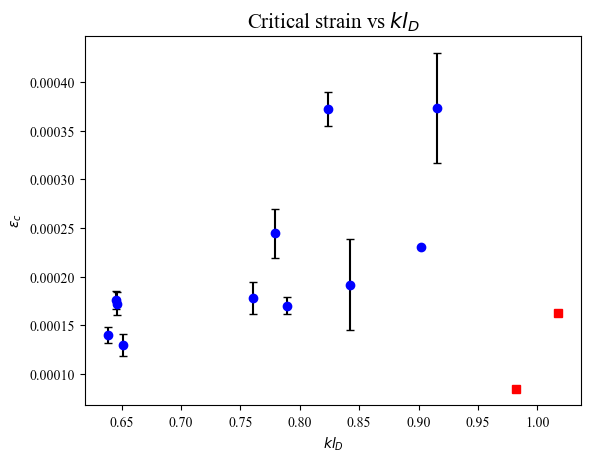

[11 12]


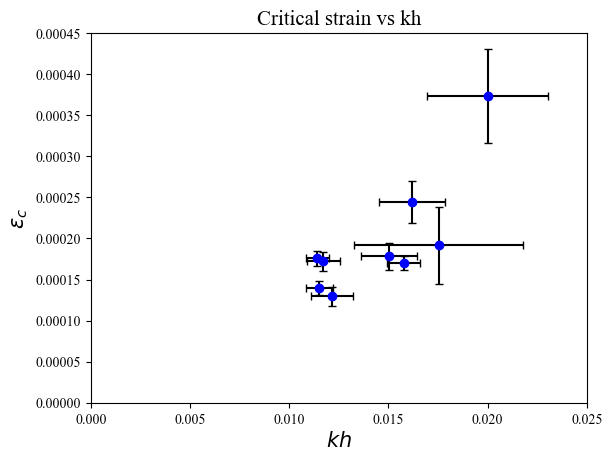

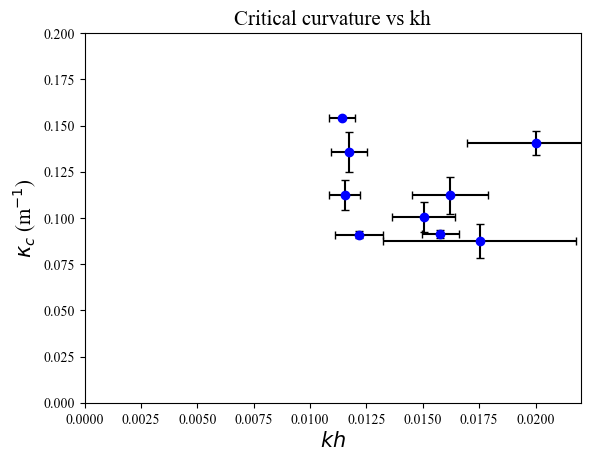

In [14]:
def omega_hydroelastic(k,D,H=17.5e-2,rho=1e3,g=9.81):
    return np.sqrt(np.tanh(k*H)*(g*k+(D/rho)*k**5))

from scipy.interpolate import interp1d
lambda_min = 5e-2
lambda_max = 5
kth = np.linspace(2*np.pi/lambda_max, 2*np.pi/lambda_min, 10000)

list_interp_fonc = []
Emoy = 2.5e9
tab_k = []
tab_D = []

for i in range(len(tab_h_avg)):
    D = (Emoy * tab_h_avg[i]**3)/(12*(1-0.3**2))
    interp_fonc = interp1d(omega_hydroelastic(kth,D),kth)
    list_interp_fonc.append(interp_fonc)
    k = interp_fonc(tab_f_exc[i]*(2*np.pi))
    tab_k.append(k)
    tab_D.append(D)

tab_k = np.array(tab_k)
tab_D = np.array(tab_D)

#plt.errorbar(tab_h_avg,np.abs(tab_kappa_avg) * tab_h_avg/2,tab_kappa_std*tab_h_avg/2,marker='o',linestyle='')
fig,ax = plt.subplots()

ax.errorbar(tab_k[indices2plot]*(tab_D[indices2plot]/(1e3*9.81))**(1/4),np.abs(tab_kappa_avg[indices2plot]) * tab_h_avg[indices2plot]/2,yerr=np.abs(tab_kappa_avg[indices2plot]) * tab_h_std[indices2plot]/2,fmt='o',linestyle='',ecolor='black',capsize=3,color='blue')
ax.errorbar(tab_k[indicesnot2plot]*(tab_D[indicesnot2plot]/(1e3*9.81))**(1/4),np.abs(tab_kappa_avg[indicesnot2plot]) * tab_h_avg[indicesnot2plot]/2,xerr=tab_h_std[indicesnot2plot],fmt='s',linestyle='',ecolor='black',capsize=3,color='red')

ax.set_title('Critical strain vs $kl_D$',fontsize=15)
ax.set_xlabel('$kl_{D}$')
ax.set_ylabel('$\epsilon_{c}$')
plt.savefig('D:/Grenoble/Gre25/Summary/fracture_postprocessing/figures/epsilonc_vs_kld.pdf',dpi=300)

#hth=np.linspace(1e-3,4e-3)
#ax.plot(hth,2e-4*(hth/2e-3)**(-1/2))
plt.show()

#################################################
# PLOTS VS kh ###################################
#################################################

indices_young = np.where(tab_h_avg<2e-3)[0]
print(indices_young)
indices2plot_older = np.where(tab_plot & (tab_h_avg>=2e-3))[0]

#plt.errorbar(tab_h_avg,np.abs(tab_kappa_avg) * tab_h_avg/2,tab_kappa_std*tab_h_avg/2,marker='o',linestyle='')
fig,ax = plt.subplots()

ax.errorbar(tab_h_avg[indices2plot_older] * tab_k[indices2plot_older],np.abs(tab_kappa_avg[indices2plot_older]) * tab_h_avg[indices2plot_older]/2,yerr=np.abs(tab_kappa_avg[indices2plot_older]) * tab_h_std[indices2plot_older]/2,xerr=tab_h_std[indices2plot_older]*tab_k[indices2plot_older],fmt='o',linestyle='',ecolor='black',capsize=3,color='blue')
#ax.errorbar(tab_h_avg[indices_young] * tab_k[indices_young],np.abs(tab_kappa_avg[indices_young]) * tab_h_avg[indices_young]/2,yerr=np.abs(tab_kappa_avg[indices_young]) * tab_h_std[indices_young]/2,xerr=tab_h_std[indices_young]*tab_k[indices_young],fmt='s',linestyle='',ecolor='black',capsize=3,color='red',label='young ice (h<2mm)')

#ax.errorbar(tab_h_avg[indicesnot2plot],np.abs(tab_kappa_avg[indicesnot2plot]) * tab_h_avg[indicesnot2plot]/2,xerr=tab_h_std[indicesnot2plot],yerr=np.abs(tab_kappa_avg[indicesnot2plot]) * tab_h_std[indicesnot2plot]/2,fmt='s',linestyle='',ecolor='black',capsize=3,color='red')

ax.set_xlim(0,0.025)
ax.set_ylim(0,4.5e-4)
ax.set_title('Critical strain vs kh',fontsize=15)
ax.set_xlabel('$kh$',fontsize=15)
ax.set_ylabel('$\epsilon_{c}$',fontsize=15)
#plt.loglog()
#plt.legend()
plt.savefig('D:/Grenoble/Gre25/Summary/fracture_postprocessing/figures/epsilonc_vs_kh.pdf',dpi=600)
#hth=np.linspace(1e-3,4e-3)
#ax.plot(hth,2e-4*(hth/2e-3)**(-1/2))
plt.show()



fig,ax = plt.subplots()
#ax.errorbar(tab_h_avg[indices2plot] * tab_k[indices2plot],np.abs(tab_kappa_avg[indices2plot]),yerr=tab_kappa_std[indices2plot],xerr=tab_h_std[indices2plot]* tab_k[indices2plot],fmt='o',linestyle='',ecolor='black',capsize=3,color='blue')
ax.errorbar(tab_h_avg[indices2plot_older] * tab_k[indices2plot_older],np.abs(tab_kappa_avg[indices2plot_older]),yerr=tab_kappa_std[indices2plot_older],xerr=tab_h_std[indices2plot_older]* tab_k[indices2plot_older],fmt='o',linestyle='',ecolor='black',capsize=3,color='blue')
#ax.errorbar(tab_h_avg[indices_young] * tab_k[indices_young],np.abs(tab_kappa_avg[indices_young]),yerr=tab_kappa_std[indices_young],xerr=tab_h_std[indices_young]* tab_k[indices_young],fmt='s',linestyle='',ecolor='black',capsize=3,color='red',label='young ice (h<2mm)')


#ax.errorbar(tab_h_avg[indicesnot2plot],np.abs(tab_kappa_avg[indicesnot2plot]),tab_kappa_std[indicesnot2plot],fmt='s',linestyle='',ecolor='black',capsize=3,color='red')

ax.set_ylim(0,0.2)
ax.set_xlim(0,0.022)
ax.set_title('Critical curvature vs kh',fontsize=15)
ax.set_xlabel('$kh$',fontsize=15)
ax.set_ylabel('$\kappa_{c}$ (m$^{-1}$)',fontsize=15)
#ax.set_xscale('log')
#ax.set_yscale('log')
#plt.legend()
plt.savefig('D:/Grenoble/Gre25/Summary/fracture_postprocessing/figures/kappac_vs_kh.pdf',dpi=300)
plt.show()


## essai d'utiliser les RDD pour afficher kappac vs D

<>:12: SyntaxWarning: invalid escape sequence '\k'
<>:12: SyntaxWarning: invalid escape sequence '\k'
C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_14564\3728535958.py:12: SyntaxWarning: invalid escape sequence '\k'
  ax.set_ylabel('$\kappa_{c}$ (m$^{-1}$)')


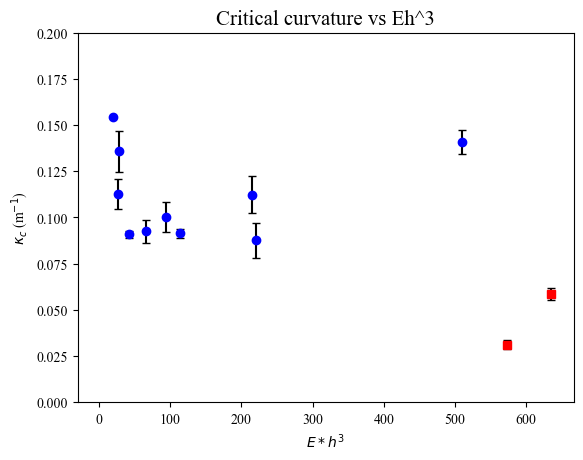

In [154]:
# on fait une grosse supposition sur E vs h
tab_E_computed = 135731602066278.92*tab_h_avg**2 -462457927825.84863*tab_h_avg + 2028967959.7081296

fig,ax = plt.subplots()
ax.errorbar(tab_E_computed[indices2plot] * tab_h_avg[indices2plot]**3,np.abs(tab_kappa_avg[indices2plot]),tab_kappa_std[indices2plot],fmt='o',linestyle='',ecolor='black',capsize=3,color='blue')
ax.errorbar(tab_E_computed[indicesnot2plot] * tab_h_avg[indicesnot2plot]**3,np.abs(tab_kappa_avg[indicesnot2plot]),tab_kappa_std[indicesnot2plot],fmt='s',linestyle='',ecolor='black',capsize=3,color='red')

ax.set_ylim(0,0.2)
#ax.set_xlim(0,6e-3)
ax.set_title('Critical curvature vs Eh^3',fontsize=15)
ax.set_xlabel('$E*h^3$ ')
ax.set_ylabel('$\kappa_{c}$ (m$^{-1}$)')
plt.savefig('R:/Gre25/Summary/fracture_postprocessing/figures/kappac_vs_D.pdf',dpi=300)
plt.show()

## comparaison avec les amplitudes critiques trouvées à la main sur imagej

In [155]:
sys.path.append('C:/Users/Vasco Zanchi/Documents/git_turbotice/')

from vasco.tools import open_csv
csv_file_path = 'R:/Gre25/Summary/Table_experiences.csv'

(dict_lists , list_categories , list_types) = open_csv.open_csv_table_experiments(csv_file_path,delimiter=',')



In [156]:
# on ajoute le point "propre" de 2024
thicknesses_20241129 = np.array([3.12,3.04,3.74,3.28,3.52,3.15,4.16,3.79,3.85,3.84,3.59,3.55])
Ac_20241129 = 6 # mm
h_avg_20241129 = np.mean(thicknesses_20241129)
h_std_20241129 = np.std(thicknesses_20241129)
print(h_avg_20241129,'+-',h_std_20241129)

tab_h_avg_frac = np.array(dict_lists['h_avg_frac'])
tab_h_std_frac = np.array(dict_lists['h_std_frac'])
tab_Ac_ice_centre = np.array(dict_lists['Ac_ice_centre_mm'])
tab_err_Ac = np.array(dict_lists['Ac_ice_centre_mm_err'])

indices_to_plot = np.where(np.array(dict_lists['plot'])=='True')
print(indices_to_plot)
other_indices = np.where(np.array(dict_lists['plot'])=='False')
print(indices_to_plot)





3.5524999999999998 +- 0.33169074451965047
(array([ 0,  2,  3,  5,  6,  8, 10, 13, 14, 15]),)
(array([ 0,  2,  3,  5,  6,  8, 10, 13, 14, 15]),)


Text(0, 0.5, 'Kappa_c (m^-1)')

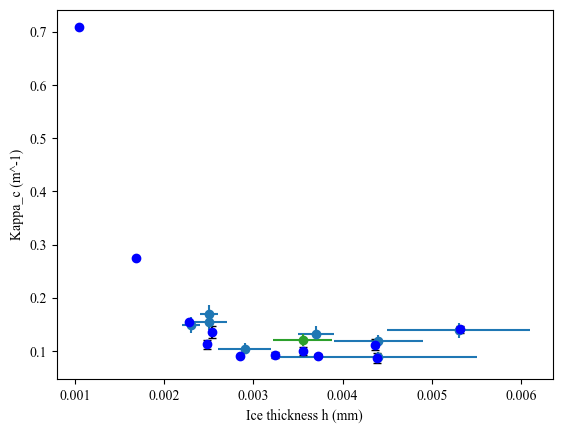

In [157]:
%matplotlib inline
plt.figure()
plt.errorbar(tab_h_avg_frac[indices_to_plot]*1e-3,1e-3 * tab_Ac_ice_centre[indices_to_plot]*(2*np.pi/1.4)**2,xerr=1e-3*tab_h_std_frac[indices_to_plot],yerr=1e-3 * tab_err_Ac[indices_to_plot]*(2*np.pi/1.4)**2, marker='o',linestyle='')
#plt.errorbar(tab_h_avg_frac[other_indices],tab_Ac_ice_centre[other_indices],xerr=tab_h_std_frac[other_indices],yerr=tab_err_Ac[other_indices], marker='o',linestyle='')
plt.errorbar(h_avg_20241129*1e-3,1e-3 * Ac_20241129*(2*np.pi/1.4)**2,xerr=1e-3*h_std_20241129,yerr=1e-3 * 0.1*Ac_20241129*(2*np.pi/1.4)**2,marker='o',linestyle='',color='tab:green')
plt.errorbar(tab_h_avg[indices2plot],np.abs(tab_kappa_avg[indices2plot]),tab_kappa_std[indices2plot],fmt='o',linestyle='',ecolor='black',capsize=3,color='blue')

plt.xlabel('Ice thickness h (mm)')
plt.ylabel('Kappa_c (m^-1)')
#plt.xlim(0,10)
#plt.ylim(0,12)
#plt.loglog()


In [37]:
plt.show()